In [1]:
# Original sentiment corpus exploration
#
# This pipeline analyses original sentiment data only from:
#     csvs/chunked/chunks_all.csv
#
# It uses the exact same base and custom stopword vocabulary as the
# policy exploration pipeline. No sentiment-specific stopwords are added.
# The accented French word "très" is explicitly removed, and the OCR
# form "trs" is first normalised to "très".
#
# All original sentiment data is treated as European.
#
# It generates PNG files for three scopes:
#     1. Europe-wide: all original sentiment chunks
#     2. France: the French subset
#     3. Ireland: the Irish subset
#
# Every generated PNG filename ends with `_sentiment.png`.
#
# Synthetic sentiment is excluded.
# France and Ireland are reported as subsets of the Europe-wide corpus.
# The source-count figure uses exactly three mutually exclusive groups:
# France, Ireland, and Other European.
# All summaries, scope assignments, and top-keyword tables are printed
# directly in the notebook. No CSV files are generated.

import re
import shutil
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS


def find_project_root(start=None):
    # Locate the MSC project through its csvs and markdown directories.
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start.resolve()] + list(start.resolve().parents):
        if (candidate / "csvs").exists() and (candidate / "markdown").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run the notebook from inside the MSC project."
    )


PROJECT_ROOT = find_project_root()

CHUNKS_ALL = PROJECT_ROOT / "csvs" / "chunked" / "chunks_all.csv"
PIPELINE_DIR = PROJECT_ROOT / "progress" / "exploration" / "sentiment"
IMG_DIR = PIPELINE_DIR / "img"

IMG_DIR.mkdir(parents=True, exist_ok=True)

# Remove CSV files generated by earlier versions of this pipeline.
for stale_csv in PIPELINE_DIR.rglob("*.csv"):
    stale_csv.unlink()

# Remove an empty legacy output directory if it remains.
legacy_output_dir = PIPELINE_DIR / "output"
if legacy_output_dir.exists() and not any(legacy_output_dir.iterdir()):
    legacy_output_dir.rmdir()

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

NLTK_DATA_DIR = PROJECT_ROOT / "data" / "auto"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)

if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.append(str(NLTK_DATA_DIR))

try:
    nltk.download("stopwords", download_dir=str(NLTK_DATA_DIR), quiet=True)
except Exception as exc:
    print(f"Warning: NLTK stopwords unavailable: {exc}")

print("Project root:", PROJECT_ROOT)
print("Input file:", CHUNKS_ALL)
print("PNG output directory:", IMG_DIR)

Project root: /home/nsirim/Github/mscdsa/msc
Input file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
PNG output directory: /home/nsirim/Github/mscdsa/msc/progress/exploration/sentiment/img


In [2]:
# Scope classification configuration
#
# Every original sentiment document belongs to the European corpus.
# For the source-count figure, each document is assigned to exactly one
# mutually exclusive subgroup:
#     1. France
#     2. Ireland
#     3. Other European
#
# The `country` column is checked first when populated. In the sentiment
# corpus it is generally empty, so filenames and document identifiers are
# used as the principal evidence.
#
# Exact filename overrides may be added for ambiguous documents.
# Allowed values are "France", "Ireland", and "Other European".

SCOPE_OVERRIDES_BY_FILENAME = {
    # "example_report.pdf": "Other European",
}

IRELAND_PATTERNS = [
    r"\bireland\b",
    r"\birish\b",
    r"\bimportant[_\-\s]*ireland\b",
    r"\bqqi\b",
    r"\boco[_\-\s]*ai[_\-\s]*and[_\-\s]*us\b",
]

FRANCE_PATTERNS = [
    r"\bfrance\b",
    r"\bfrench\b",
    r"\bfrancais\b",
    r"\bfrançais\b",
    r"\bimportant[_\-\s]*france\b",
]

ALLOWED_EXPLORATION_SCOPES = {
    "France",
    "Ireland",
    "Other European",
}


def normalise_descriptor(value):
    value = "" if pd.isna(value) else str(value)
    value = unicodedata.normalize("NFKC", value)
    value = value.lower().replace("_", " ").replace("-", " ")
    return re.sub(r"\s+", " ", value).strip()


def first_matching_pattern(text, patterns):
    for pattern in patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            return pattern
    return None


def infer_scope(row):
    filename = str(row.get("filename", "") or "")
    override = SCOPE_OVERRIDES_BY_FILENAME.get(filename.lower())

    if override:
        if override not in ALLOWED_EXPLORATION_SCOPES:
            raise ValueError(
                f"Invalid scope override for {filename}: {override}"
            )

        return pd.Series(
            {
                "exploration_scope": override,
                "scope_reason": "manual filename override",
            }
        )

    country = normalise_descriptor(row.get("country", ""))

    if country in {"ireland", "irish"}:
        return pd.Series(
            {
                "exploration_scope": "Ireland",
                "scope_reason": f"country metadata: {country}",
            }
        )

    if country in {"france", "french"}:
        return pd.Series(
            {
                "exploration_scope": "France",
                "scope_reason": f"country metadata: {country}",
            }
        )

    descriptor_fields = [
        "filename",
        "source_file",
        "relative_source_file",
        "doc_id",
    ]
    descriptor = " ".join(
        normalise_descriptor(row.get(field, ""))
        for field in descriptor_fields
    )

    # Ireland is checked first because one existing source name contains
    # a France prefix but an explicit Ireland suffix.
    ireland_match = first_matching_pattern(
        descriptor,
        IRELAND_PATTERNS,
    )
    if ireland_match:
        return pd.Series(
            {
                "exploration_scope": "Ireland",
                "scope_reason": f"source cue: {ireland_match}",
            }
        )

    france_match = first_matching_pattern(
        descriptor,
        FRANCE_PATTERNS,
    )
    if france_match:
        return pd.Series(
            {
                "exploration_scope": "France",
                "scope_reason": f"source cue: {france_match}",
            }
        )

    return pd.Series(
        {
            "exploration_scope": "Other European",
            "scope_reason": (
                "European source without an explicit France or Ireland cue"
            ),
        }
    )

In [3]:
# Load and filter original sentiment chunks.

if not CHUNKS_ALL.exists():
    raise FileNotFoundError(f"Missing input file: {CHUNKS_ALL}")

df = pd.read_csv(CHUNKS_ALL, encoding="utf-8-sig")

required_columns = {
    "doc_id",
    "corpus",
    "source_type",
    "heading_context",
    "chunk_text",
}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

for optional_column in [
    "filename",
    "source_file",
    "relative_source_file",
    "country",
]:
    if optional_column not in df.columns:
        df[optional_column] = ""

df["corpus"] = df["corpus"].fillna("").astype(str).str.lower()
df["source_type"] = df["source_type"].fillna("").astype(str).str.lower()
df["heading_context"] = df["heading_context"].fillna("").astype(str)
df["chunk_text"] = df["chunk_text"].fillna("").astype(str)

df = df[
    df["corpus"].eq("sentiment")
    & df["source_type"].eq("original")
].copy()

df = df[
    df["chunk_text"].str.strip().ne("")
    & df["chunk_text"].str.strip().ne("N/A")
].copy()

if df.empty:
    raise ValueError("No original sentiment chunks were found.")

artifact_heading_pattern = re.compile(
    r"^(contents|table of contents|acknowledgements?|acknowledgments?|"
    r"acronyms?|abbreviations?|bibliography|references|cover|copyright|"
    r"appendix|annex|figures?|tables?|foreword|preface)$",
    re.IGNORECASE,
)

artifact_text_pattern = re.compile(
    r"(table of contents|all rights reserved|isbn|bibliography|"
    r"cover photo|printed by|creative commons|doi\.org|"
    r"directorate of communications)",
    re.IGNORECASE,
)

heading_artifact = (
    df["heading_context"]
    .str.strip()
    .str.match(artifact_heading_pattern)
)
text_artifact = (
    df["chunk_text"]
    .str[:900]
    .str.contains(artifact_text_pattern, regex=True, na=False)
)

removed_artifact_chunks = int((heading_artifact | text_artifact).sum())
df = df.loc[~(heading_artifact | text_artifact)].copy()


def combine_heading_and_chunk(row):
    heading = re.sub(r"\s+", " ", row["heading_context"]).strip()
    chunk = re.sub(r"\s+", " ", row["chunk_text"]).strip()

    if not heading or chunk.lower().startswith(heading.lower()):
        return chunk

    return f"{heading}. {chunk}"


df["analysis_text"] = df.apply(combine_heading_and_chunk, axis=1)

scope_fields = df.apply(infer_scope, axis=1)
df = pd.concat([df, scope_fields], axis=1)

inconsistent_scope_docs = (
    df.groupby("doc_id")["exploration_scope"].nunique().loc[lambda x: x > 1]
)
if len(inconsistent_scope_docs):
    raise ValueError(
        "Inconsistent scope assignments for documents: "
        f"{inconsistent_scope_docs.index.tolist()}"
    )

print("Original sentiment chunks retained:", len(df))
print("Original sentiment documents retained:", df["doc_id"].nunique())
print("Removed document-artifact chunks:", removed_artifact_chunks)

print("\nChunks by exploration scope:")
print(df["exploration_scope"].value_counts(dropna=False).to_string())

print("\nDocuments by exploration scope:")
print(
    df.groupby("exploration_scope")["doc_id"]
    .nunique()
    .sort_values(ascending=False)
    .to_string()
)

print("\nDocument scope assignments:")
scope_assignment = (
    df[
        [
            "doc_id",
            "filename",
            "country",
            "exploration_scope",
            "scope_reason",
        ]
    ]
    .drop_duplicates(subset=["doc_id"])
    .sort_values(["exploration_scope", "filename", "doc_id"])
    .reset_index(drop=True)
)
display(scope_assignment)

Original sentiment chunks retained: 500
Original sentiment documents retained: 17
Removed document-artifact chunks: 36

Chunks by exploration scope:
exploration_scope
Other European    287
Ireland           168
France             45

Documents by exploration scope:
exploration_scope
Other European    9
France            4
Ireland           4

Document scope assignments:


,doc_id,filename,country,exploration_scope,scope_reason
0,sentiment_original_20251119_les_francais_lia,20251119-Les-Francais-lIA.md,NaN,France,source cue: \bfrancais\b
1,sentiment_original_french_digital_society_digital_mediation_professionals_face_the_challenge_of_digital_remoteness_labo,French digital society_ digital mediation professionals face the challenge of digital remoteness - Labo.md,NaN,France,source cue: \bfrench\b
2,sentiment_original_how_do_the_french_relate_to_artificial_intelligence_labo,How do the French relate to artificial intelligence_ - Labo.md,NaN,France,source cue: \bfrench\b
3,sentiment_original_les_jeunes_fran_ais_face_l_ia_g_n_rative_usages_perceptions_et_app_tence_pour_les_formations_d_di_es_ifop_group,"Les jeunes Français face à l’IA générative _ usages, perceptions et appétence pour les formations dédiées - Ifop Group.md",NaN,France,source cue: \bfrançais\b
4,sentiment_original_ai_is_a_threat_to_the_essence_of_education_the_irish_times,AI is a threat to the essence of education – The Irish Times.md,NaN,Ireland,source cue: \birish\b
5,sentiment_original_ai4t_wp3_d3_3_nr_ireland,AI4T_WP3_D3.3_NR_Ireland.md,NaN,Ireland,source cue: \bireland\b
6,sentiment_original_oco_ai_and_us_young_peoples_views_and_understanding_of_artificial_intelligence,OCO-AI-and-Us-Young-peoples-views-and-understanding-of-Artificial-Intelligence.md,NaN,Ireland,source cue: \boco[_\-\s]*ai[_\-\s]*and[_\-\s]*us\b
7,sentiment_original_qqi_generative_artificial_intelligence_survey_report_2025,qqi_generative-artificial-intelligence-survey-report-2025.md,NaN,Ireland,source cue: \bqqi\b
8,sentiment_original_051024_insights_into_ai_and_the_youth_sector,051024_Insights into AI and the youth sector.md,NaN,Other European,European source without an explicit France or Ireland cue
9,sentiment_original_3remittancesreview_volume8_issue4saajdmalakand,3RemittancesReview-Volume8-Issue4Saajdmalakand.md,NaN,Other European,European source without an explicit France or Ireland cue


In [4]:
# Text cleaning and stopword removal
#
# The stopword vocabulary below is copied directly from the policy
# exploration pipeline so that policy and sentiment word clouds use the
# same lexical exclusions. No additional sentiment-specific stopwords
# are introduced.

# Base stop words initialization
stop_words = set(SPACY_STOP_WORDS)
stop_words.update(set(stopwords.words('english')))

# Add French Stopwords
try:
    french_stopwords = set(stopwords.words('french'))
    stop_words.update(french_stopwords)
except:
    print("Warning: French stopwords not found.")

# ============================================================
# Reorganized custom stopwords
# Goal:
# - Keep the same stopword vocabulary
# - Make categories clearer and more accurate
# - Apply these AFTER clean_text()
# ============================================================


# ------------------------------------------------------------
# 1. PDF, scraping, formatting, and document extraction artifacts
# ------------------------------------------------------------
document_artifact_stopwords = [
    'pdf', 'qxp', 'page', 'copyright', 'reserved',
    'www', 'http', 'https', 'com', 'org',
    'figure', 'table', 'annex', 'appendix', 'footnote', 'endnote',
    'isbn', 'bibliography', 'citation', 'reference', 'metadata', 'docx',
    'executive summary', 'draft', 'matrix', 'blueprint', 'snapshot',
    'chart', 'brochure',
    'fig'
]


# ------------------------------------------------------------
# 2. Legal and policy document structure words
# These usually describe the document format, not the policy topic
# ------------------------------------------------------------
legal_structure_stopwords = [
    'section', 'chapter', 'part', 'title', 'article', 'clause',
    'paragraph', 'subparagraph', 'schedule', 'exhibit', 'supplement',
    'addendum', 'preamble', 'recital', 'report',

    # French structure words
    'chapitre', 'partie', 'titre', 'paragraphe', 'alinea',
    'annexe', 'appendice', 'expos', 'des', 'motifs',
    'disposition'
]


# ------------------------------------------------------------
# 3. Legal / bureaucratic boilerplate
# These are legal phrasing words, not substantive keywords
# ------------------------------------------------------------
legal_boilerplate_stopwords = [
    'coppa', 'ferpa', 'enact', 'bit',
    'herein', 'therein', 'thereof', 'whereof', 'hereby',
    'whereby', 'hereinafter', 'thereafter', 'aforementioned',
    'foregoing', 'henceforth', 'whereto', 'whereupon',
    'notwithstanding', 'pursuant', 'thereto', 'thereunder', 'hereto',

    # French legal / OCR-normalized forms
    'susmentionn', 'prcit', 'nonobstant', 'par drogation',
    'en', 'consquence', 'eu', 'gard', 'aux fins',
    'selon', 'conformment', 'outre', 'ladite', 'ledit', 'dune'
]


# ------------------------------------------------------------
# 4. Modal, obligation, and policy-action verbs
# These often dominate policy texts but are not domain keywords
# ------------------------------------------------------------
policy_action_stopwords = [
    'shall', 'must', 'may', 'might', 'could', 'would', 'should', 'will',
    'require', 'requires', 'required',
    'ensure', 'ensures',
    'seek', 'seeks', 'seeking',
    'establish', 'establishes',
    'promote', 'promotes', 'promoting',
    'maintain', 'respect',

    # French equivalents / OCR-normalized forms
    'doit', 'devrait', 'pourrait', 'vouloir',
    'exiger', 'requis', 'assurer', 'garantir',
    'rechercher', 'tablir', 'promouvoir',
    'maintenir', 'respecter'
]


# ------------------------------------------------------------
# 5. Generic policy connectors and vague qualifiers
# These help grammar but rarely reveal the policy theme
# ------------------------------------------------------------
policy_connector_stopwords = [
    'various', 'several', 'multiple', 'certain', 'relevant', 'appropriate',
    'regarding', 'concerning', 'involving', 'accordance',
    'relate', 'relates', 'relating',
    'furthermore', 'moreover', 'therefore', 'thus', 'hence',
    'however', 'although', 'including', 'etc', 'etcetera',

    # French equivalents
    'concernant', 'divers', 'plusieurs', 'particulier',
    'certain', 'aussi', 'de plus', 'en outre',
    'par consquent', 'donc', 'ainsi', 'cependant',
    'bien que', 'notamment', 'entre autres', 'comme',
    'toute', 'tous', 'cette', 'plus', 'leurs'
]


# ------------------------------------------------------------
# 6. Geographic, national, governmental, and institutional noise
# Useful to remove if you compare policy themes rather than countries
# ------------------------------------------------------------
geo_institutional_stopwords = [
    'ireland', 'irish', 'france', 'french', 'usa', 'america',
    'australia', 'australian',
    'country', 'nation', 'national', 'state',
    'government', 'federal', 'ministry', 'department',
    'gouvernement', 'ministre', 'dtat', 'republic',
    'pittsburg', 'antioch', 'medina', 'winterset',
    'sara', 'washington', 'california', 'massachusetts',
    'oregon', 'sweden', 'unified', 'district',
    'commonwealth', 'nsw'
]


# ------------------------------------------------------------
# 7. AI, digital, technology, vendor, and model-name noise
# Be careful: remove these only if you want deeper policy themes,
# not surface AI vocabulary.
# ------------------------------------------------------------
tech_ai_stopwords = [
    'artificial', 'intelligence',
    'ai', 'ia', 'lia', 'lIA', 'dia', 'dIA',
    'genai', 'generative',
    'model', 'models', 'llm',
    'algorithm', 'algorithms',
    'machine', 'learning',
    'data', 'dataset', 'datasets',
    'digital', 'numrique',
    'computer', 'software', 'hardware',
    'technology', 'technological',
    'platform', 'online', 'internet', 'web', 'electronic',
    'tool', 'system', 'device', 'application', 'app', 'service',
    'broadband', 'connectivity', 'vendor', 'player', 'enterprise',

    # French / OCR-normalized technical terms
    'artificielle', 'gen', 'generatif',
    'modle', 'modles',
    'apprentissage', 'donn',
    'ordinateur', 'logiciel', 'matriel',
    'technologie', 'plateforme', 'ligne',
    'ectronique', 'outil', 'systme', 'dispositif',
    'générative', 'intelligent',

    # Vendors, systems, and model-related terms
    'edge', 'gpt', 'openai', 'microsoft', 'google',
    'amazon', 'meta', 'ibm', 'nvidia', 'intel',
    'gemini', 'deepseek', 'anthropic', 'claude',
    'embedding', 'transformer', 'natural language',
    'climate change', 'ieee', 'architecture',
    'chatgtp', 'copilot', 'kwyk', 'technologies',

    # Extra English terms seen in the French corpus
    'new', 'work', 'law', 'system', 'systems', 'right',
    'services', 'based', 'case', 'support', 'human',
    'generated', 'related'
]


# ------------------------------------------------------------
# 8. Education-system generic terms
# Remove these if the whole corpus is already about education.
# Keep them if you want education-specific keywords.
# ------------------------------------------------------------
education_stopwords = [
    'school', 'education', 'educational',
    'pupil', 'classroom', 'learning',
    'teacher', 'teachers', 'schools',
    'student', 'students',
    'post', 'primary', 'technical',

    # French education terms and OCR variants
    'cole', 'educatif', 'enseignant', 'enseignats', 'enseignants',
    'professeur', 'programme',
    'apprentissage', 'enseignement', 'formation',
    'établissement', 'éducation', 'école',
    'élève', 'élèves',

    # Other education/project terms
    'covid', 'showcase', 'deliverable'
]


# ------------------------------------------------------------
# 9. Organizations, people, acronyms, and named entities
# ------------------------------------------------------------
org_name_stopwords = [
    'adam', 'mary', 'jensen', 'abraham', 'lincoln',
    'knight', 'kim', 'guez',
    'oecd', 'cbs', 'webwise', 'cosn', 'dlf',
    'scoilnet', 'deap', 'dne', 'men',
    'parliament', 'commissioner', 'public sector',
    'cipa', 'protection act', 'oide', 'tie', 'cpd'
]


# ------------------------------------------------------------
# 10. Generic vague words and corpus-specific noise
# ------------------------------------------------------------
generic_noise_stopwords = [
    'feel', 'like', 'everybody', 'actually',
    'kid', 'employee', 'min', 'box', 'loop',
    'black', 'asset', 'typical', 'era',
    'acquire', 'behavioral', 'behavioural',
    'revolution', 'emission', 'talent',
    'billion', 'count', 'witness', 'operator',
    'interim', 'resourced', 'resourcing',
    'round', 'support work', 'dashboard',
    'ela', 'estonia', 'pisa', 'perspectives',
    'final', 'total', 'describe', 'visit',
    'original', 'sample', 'low',
    'answer', 'ask', 'efficacy',
    'deepen', 'enhance',
    'author', 'researcher', 'mission', 'personnel',
    'palo', 'alto', 'card',
    'use', 'lot', 'enable', 'constituent',
    'session', 'policy', 'document',
    'member', 'organisation', 'goal',
    'long term', 'desirable', 'young',
    'ite', 'aied', 'australasian',
    'perplexed', 'guidetoaiinschools', 'nenufsd',
    'dent', 'fee', 'want', 'prof', 'stu'
]


# ------------------------------------------------------------
# 11. Dates and temporal noise
# ------------------------------------------------------------
date_time_stopwords = [
    'july', 'april', 'august'
]


# ------------------------------------------------------------
# 12. French and English generic content words seen after cleaning
# These should be applied AFTER clean_text()
# ------------------------------------------------------------
post_cleaning_generic_stopwords = [
    'être', 'avoir', 'faire', 'peut',
    'tout', 'tous', 'toute', 'toutes',
    'autre', 'autres',
    'encore', 'déjà', 'non', 'sans',
    'dont', 'cela', 'même', 'mme',
    'très', 'moins', 'plus', 'souvent',
    'cas', 'type', 'manière', 'fonction', 'partir',
    'exemple', 'question', 'réponse', 'résultat',
    'objectif', 'contenu', 'texte', 'image'
]


# ------------------------------------------------------------
# 13. Word fragments and OCR leftovers
# ------------------------------------------------------------
fragment_stopwords = [
    'ing', 'tion', 'ment', 'ness', 'ly',
    'able', 'ive', 'ent', 'ant',
    'ence', 'ance',
    'ali', 'gue', 'rod', 'rodr',
    'educa', 'evi', 'al'
]


# ------------------------------------------------------------
# Merge all custom stopword categories
# ------------------------------------------------------------
custom_stopword_categories = [
    document_artifact_stopwords,
    legal_structure_stopwords,
    legal_boilerplate_stopwords,
    policy_action_stopwords,
    policy_connector_stopwords,
    geo_institutional_stopwords,
    tech_ai_stopwords,
    education_stopwords,
    org_name_stopwords,
    generic_noise_stopwords,
    date_time_stopwords,
    post_cleaning_generic_stopwords,
    fragment_stopwords,
]

custom_stopwords = set()

for category in custom_stopword_categories:
    custom_stopwords.update(category)


# Add to your existing stop_words
stop_words.update(custom_stopwords)

# Keep the accented French form explicit even though it is already present
# in the copied policy vocabulary.
stop_words.add("très")

# Sentiment-polarity labels are excluded because they describe the coding
# direction rather than the substantive themes of the reports.
sentiment_polarity_stopwords = {
    "positif", "positive", "positifs", "positives",
    "négatif", "negatif", "négative", "negative",
    "négatifs", "negatifs", "négatives", "negatives", 
    "sait", "numerique", "numérique", "français"
}
stop_words.update(sentiment_polarity_stopwords)

def clean_text(text):
    """
    Normalise policy text before keyword extraction.

    Important design choice:
    - This function fixes OCR/extraction issues and French contractions first.
    - Stop words are NOT changed here.
    - Stop words are removed only after clean_text() has produced normalised tokens.

    This order is important for the French corpus because forms such as l’IA, l'IA,
    d’IA and d'IA first become normal tokens such as ia, then the existing
    stop_words list can remove ia / lia / dia-style artefacts consistently.
    """
    # Lowercase first to match stopwords later
    text = str(text).lower()

    # Normalise apostrophes so l’ia and l'ia are treated the same way
    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")

    # Remove common extraction artefacts
    text = text.replace("guillemetleft", " ")
    text = text.replace("guillemetright", " ")

    # Fix frequent OCR / extraction artefacts observed in French outputs
    ocr_fixes = {
        r"\blve\b": "élève",
        r"\blves\b": "élèves",
        r"\bducation\b": "éducation",
        r"\b1ducation\b": "éducation",
        r"\bducatif\b": "éducatif",
        r"\bducative\b": "éducative",
        r"\bducatifs\b": "éducatifs",
        r"\bducatives\b": "éducatives",
        r"\btablissement\b": "établissement",
        r"\btablissements\b": "établissements",
        r"\bvaluation\b": "évaluation",
        r"\bvaluer\b": "évaluer",
        r"\btrs\b": "très",
        r"\blment\b": "élément",
        r"\blments\b": "éléments",
    }

    for pattern, replacement in ocr_fixes.items():
        text = re.sub(pattern, replacement, text)

    # Expand common French contractions before removing punctuation.
    # Example: l'IA -> la IA -> tokens: la, ia.
    french_contractions = {
        r"\bl'": "la ",
        r"\bd'": "de ",
        r"\bc'": "ce ",
        r"\bj'": "je ",
        r"\bm'": "me ",
        r"\bt'": "te ",
        r"\bs'": "se ",
        r"\bn'": "ne ",
        r"\bqu'": "que ",
        r"\blorsqu'": "lorsque ",
        r"\bpuisqu'": "puisque ",
        r"\bquoiqu'": "quoique ",
        r"\bjusqu'": "jusque ",
        r"\baujourd'": "aujourd ",
        r"\bpresqu'": "presque ",
    }

    for pattern, replacement in french_contractions.items():
        text = re.sub(pattern, replacement, text)

    # Remove email addresses
    text = re.sub(r"\S*@\S*\s?", " ", text)

    # Remove URLs and HTML tags
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text, flags=re.MULTILINE)
    text = re.sub(r"<.*?>", " ", text)

    # Remove reference citations
    text = re.sub(r"\[\d+\]", " ", text)
    text = re.sub(r"\(\s*see\s+[^\)]+\)", " ", text)
    text = re.sub(r"footnote\s*\d+", " ", text)

    # Remove standalone numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # Remove HTML entities
    text = re.sub(r"\b(amp|lt|gt|quot|nbsp)\b", " ", text)

    # Remove punctuation/separators while keeping French accented letters
    text = re.sub(r"[^a-zàâäéèêëïîôùûüÿçæœ\s-]", " ", text)

    # Return normalised tokens only. Stopword removal happens after this call.
    return text.split()


# Important short policy acronyms to preserve only if they are not stopwords.
# Because 'ai' and 'ia' are already in stop_words, they will still be removed.
important_short_terms = {"ai", "ia", "eu", "uk", "us", "un", "ocde", "oecd"}

# Extra French function words created by contraction expansion.
# This does not change stop_words; it is only a post-cleaning filter.
extra_post_clean_stopwords = {
    "la", "le", "les", "de", "un", "une", "des", "du", "au", "aux",
    "ce", "je", "me", "te", "se", "ne", "que"
}


def remove_stopwords_after_clean_text(tokens):
    """
    Remove the existing stop_words AFTER clean_text() normalisation.
    This is the step that removes French artefacts such as dia/lia when they
    appear after apostrophe/contraction normalisation.
    """
    filtered_tokens = []

    for token in tokens:
        word = token.strip("-")

        if not word:
            continue

        # Keep meaningful short acronyms only when they are not stop words.
        long_enough = len(word) > 2 or word in important_short_terms
        if not long_enough:
            continue

        # Do not change stop_words: just apply the existing list here.
        if word in stop_words:
            continue

        if word in extra_post_clean_stopwords:
            continue

        filtered_tokens.append(word)

    return filtered_tokens


# Verify that every French and English polarity variant is removed by the
# complete normalisation and stopword-filtering sequence.
_polarity_test_text = (
    "positif positive positifs positives "
    "négatif negatif négative negative "
    "négatifs negatifs négatives negatives"
)
_polarity_test_tokens = remove_stopwords_after_clean_text(
    clean_text(_polarity_test_text)
)
assert not _polarity_test_tokens, (
    "Polarity stopwords were not fully removed: "
    f"{_polarity_test_tokens}"
)
print("Polarity-stopword check passed.")


def build_keyword_text(text):
    """Full keyword-preparation pipeline: clean first, then remove stopwords."""
    tokens = clean_text(text)
    keyword_tokens = remove_stopwords_after_clean_text(tokens)
    return " ".join(keyword_tokens)

# Apply the same order as the policy pipeline:
#     1. normalise OCR and French contractions;
#     2. remove the shared stopword vocabulary.
df["clean_tokens"] = df["analysis_text"].apply(clean_text)
df["clean_tokens"] = df["clean_tokens"].apply(
    remove_stopwords_after_clean_text
)
df["processed_text"] = df["clean_tokens"].apply(" ".join)
df["processed_word_count"] = df["clean_tokens"].apply(len)

df = df[df["processed_word_count"] > 0].copy()

print("Chunks retained after shared policy-style cleaning:", len(df))
print("Total cleaned tokens:", int(df["processed_word_count"].sum()))
print(
    "Average cleaned tokens per chunk:",
    round(df["processed_word_count"].mean(), 2),
)

print("\nStopword checks:")
for checked_word in [
    "très", "trs",
    "positif", "positive", "positifs", "positives",
    "négatif", "negatif", "négative", "negative",
    "négatifs", "negatifs", "négatives", "negatives",
    "policy", "shall", "report",
]:
    count = sum(
        tokens.count(checked_word)
        for tokens in df["clean_tokens"]
    )
    print(f"  {checked_word}: {count}")

scope_order = [
    "France",
    "Ireland",
    "Other European",
]

scope_summary = (
    df.groupby("exploration_scope", dropna=False)
    .agg(
        chunks=("doc_id", "size"),
        documents=("doc_id", "nunique"),
        cleaned_tokens=("processed_word_count", "sum"),
        average_cleaned_tokens=("processed_word_count", "mean"),
    )
    .reindex(scope_order)
    .fillna(0)
    .reset_index()
)

europe_summary = pd.DataFrame(
    [
        {
            "exploration_scope": "Europe-wide total",
            "chunks": len(df),
            "documents": df["doc_id"].nunique(),
            "cleaned_tokens": int(
                df["processed_word_count"].sum()
            ),
            "average_cleaned_tokens": (
                df["processed_word_count"].mean()
            ),
        }
    ]
)

full_scope_summary = pd.concat(
    [europe_summary, scope_summary],
    ignore_index=True,
)

print("\nExploration summary:")
display(full_scope_summary)

Polarity-stopword check passed.
Chunks retained after shared policy-style cleaning: 500
Total cleaned tokens: 50373
Average cleaned tokens per chunk: 100.75

Stopword checks:
  très: 0
  trs: 0
  positif: 0
  positive: 0
  positifs: 0
  positives: 0
  négatif: 0
  negatif: 0
  négative: 0
  negative: 0
  négatifs: 0
  negatifs: 0
  négatives: 0
  negatives: 0
  policy: 0
  shall: 0
  report: 0

Exploration summary:


,exploration_scope,chunks,documents,cleaned_tokens,average_cleaned_tokens
0,Europe-wide total,500,17,50373,100.746000
1,France,45,4,3768,83.733333
2,Ireland,168,4,14896,88.666667
3,Other European,287,9,31709,110.484321


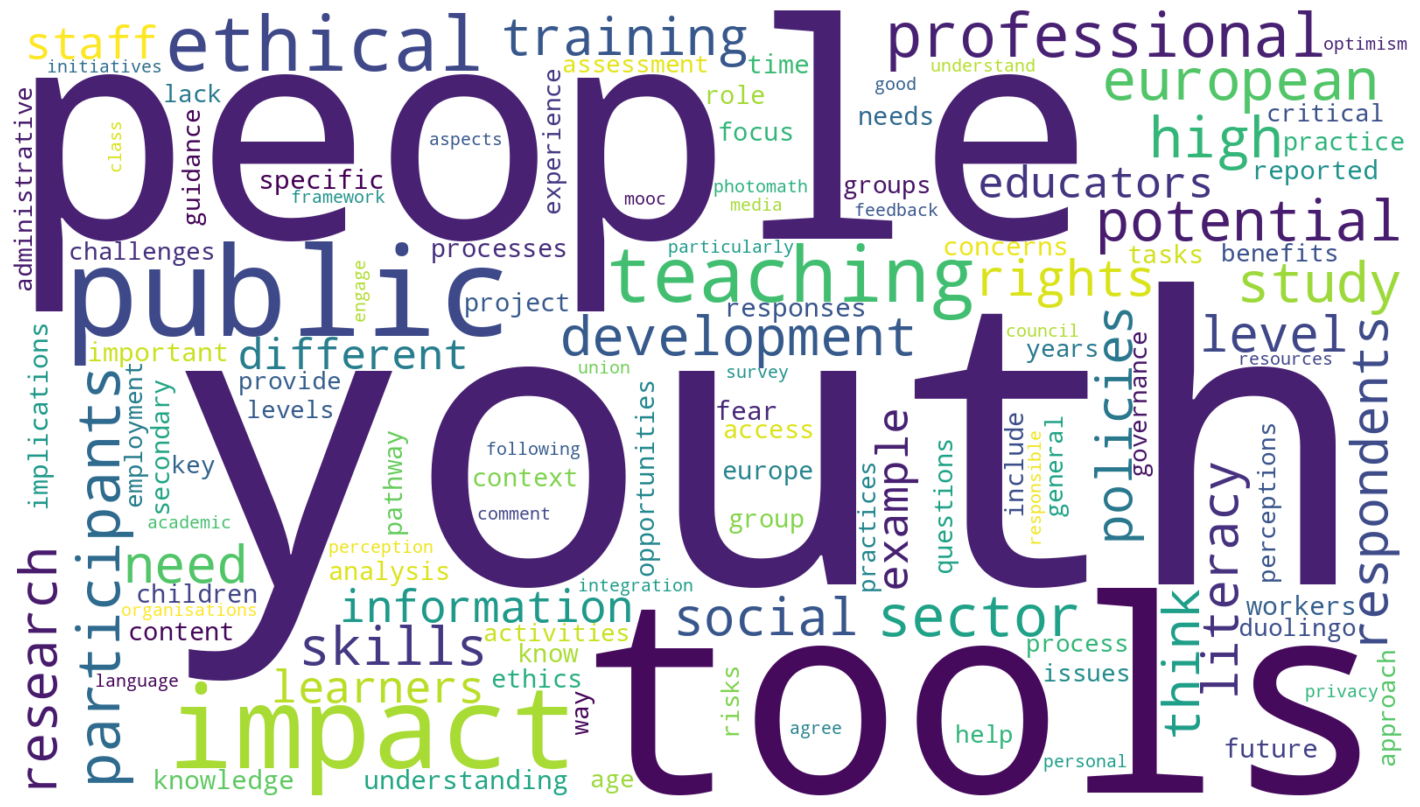

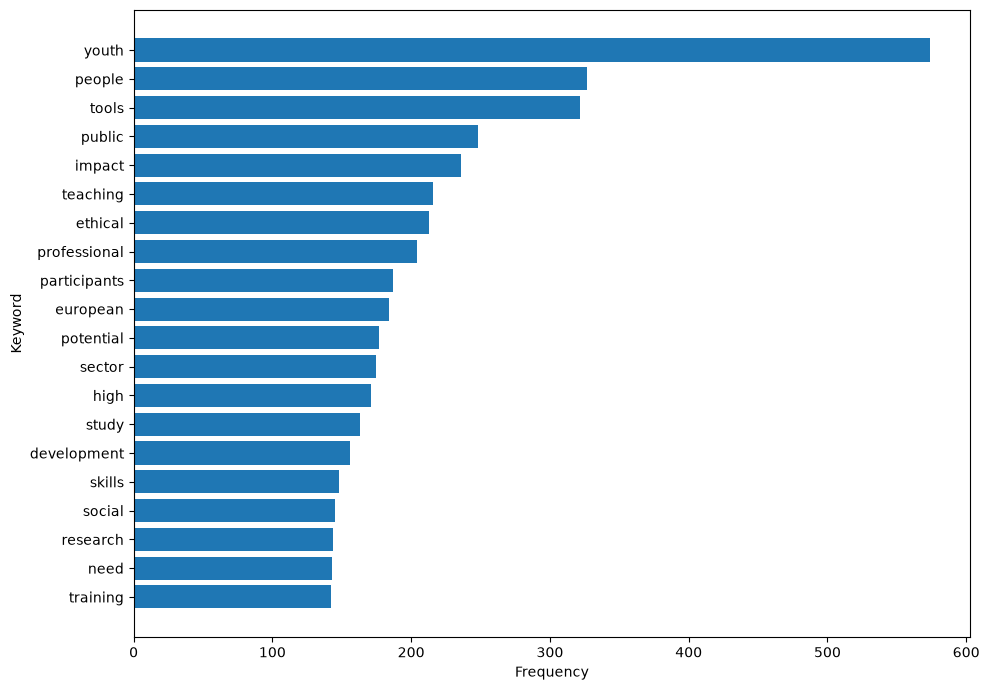


Europe: 500 chunks, 17 documents, 50373 cleaned tokens.
Top 20 keywords for Europe:


,keyword,frequency
0,youth,574
1,people,327
2,tools,322
3,public,248
4,impact,236
5,teaching,216
6,ethical,213
7,professional,204
8,participants,187
9,european,184


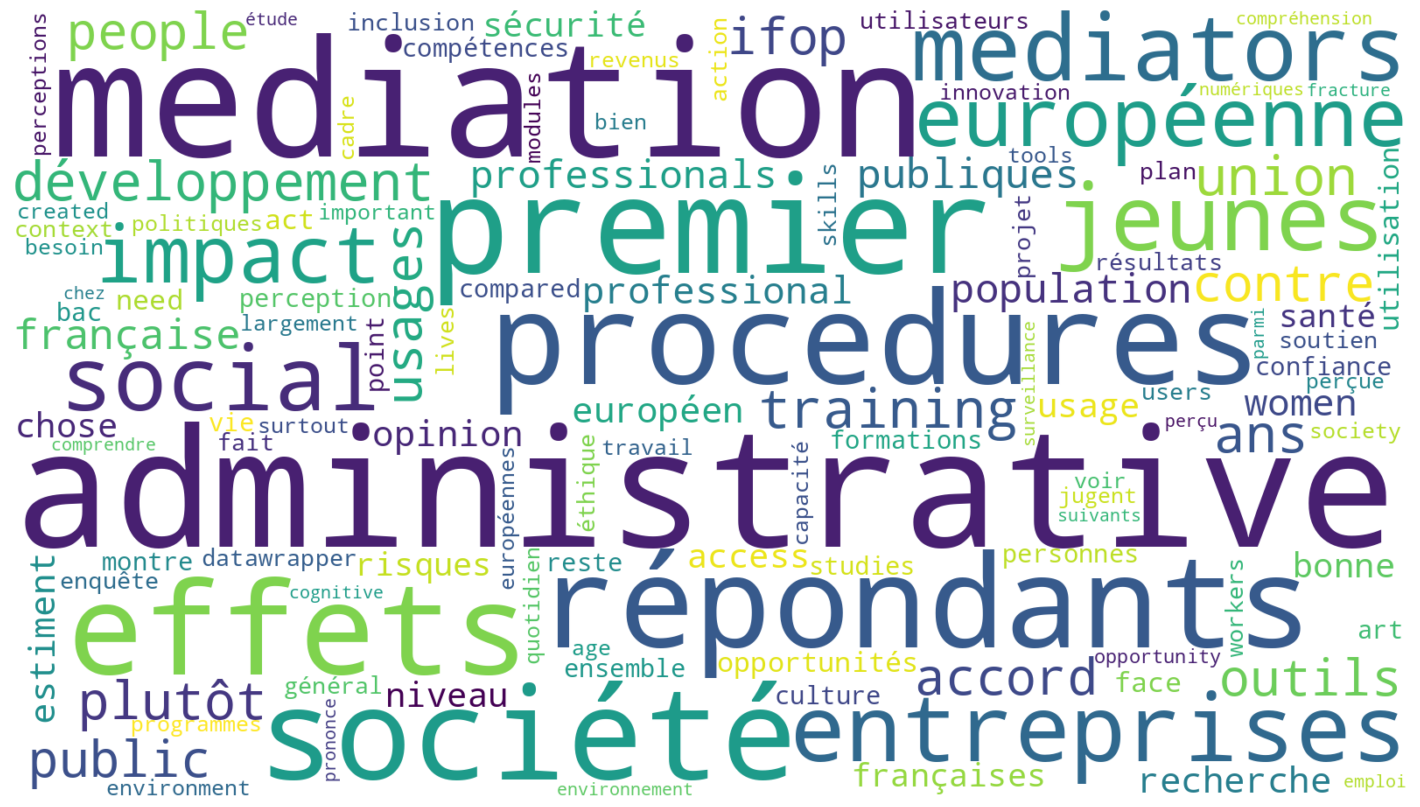

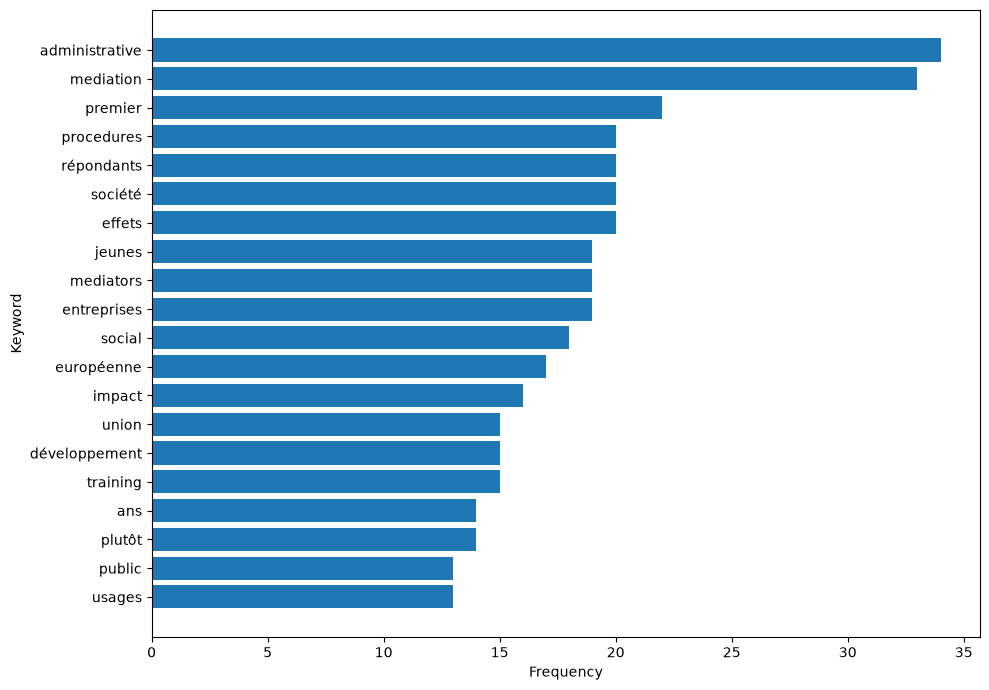


France: 45 chunks, 4 documents, 3768 cleaned tokens.
Top 20 keywords for France:


,keyword,frequency
0,administrative,34
1,mediation,33
2,premier,22
3,société,20
4,répondants,20
5,effets,20
6,procedures,20
7,entreprises,19
8,mediators,19
9,jeunes,19


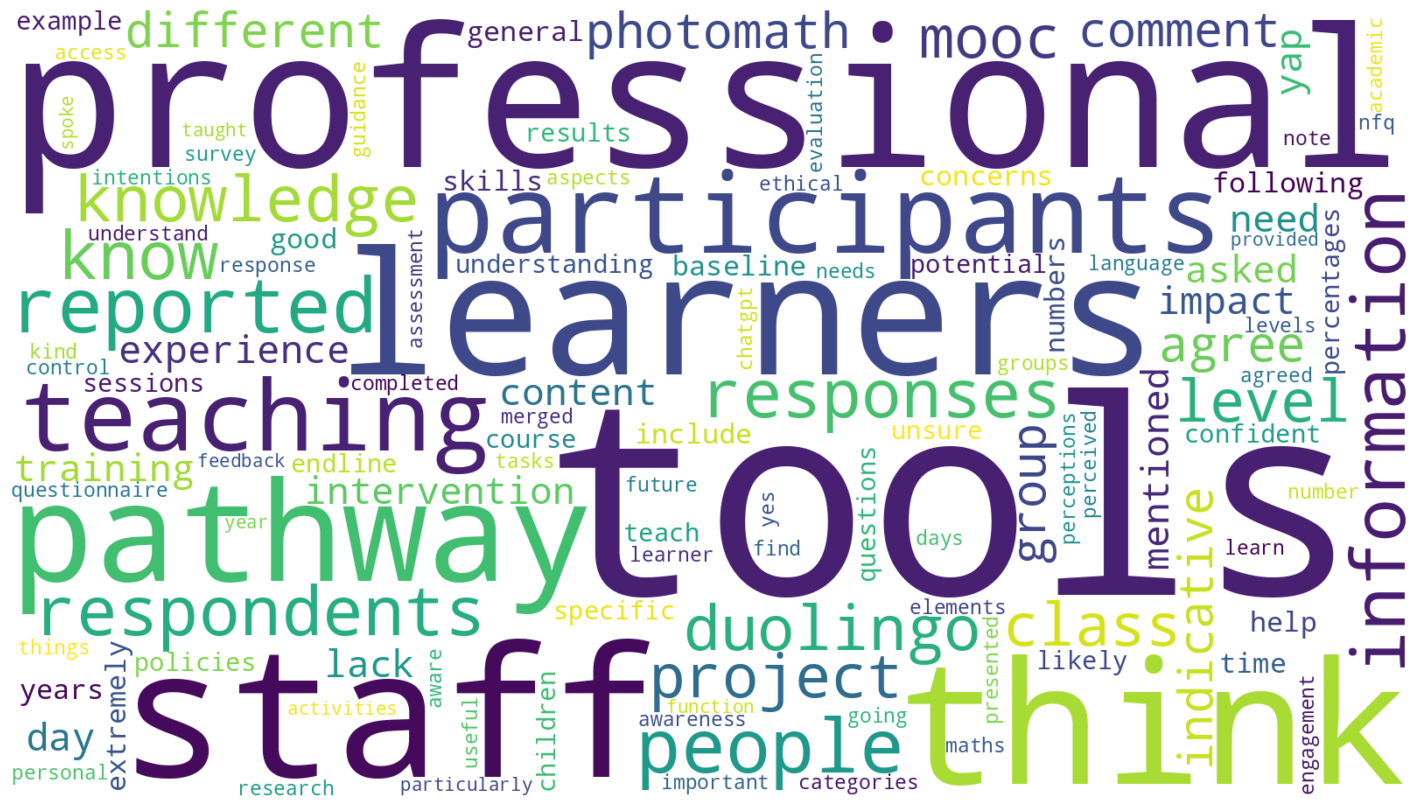

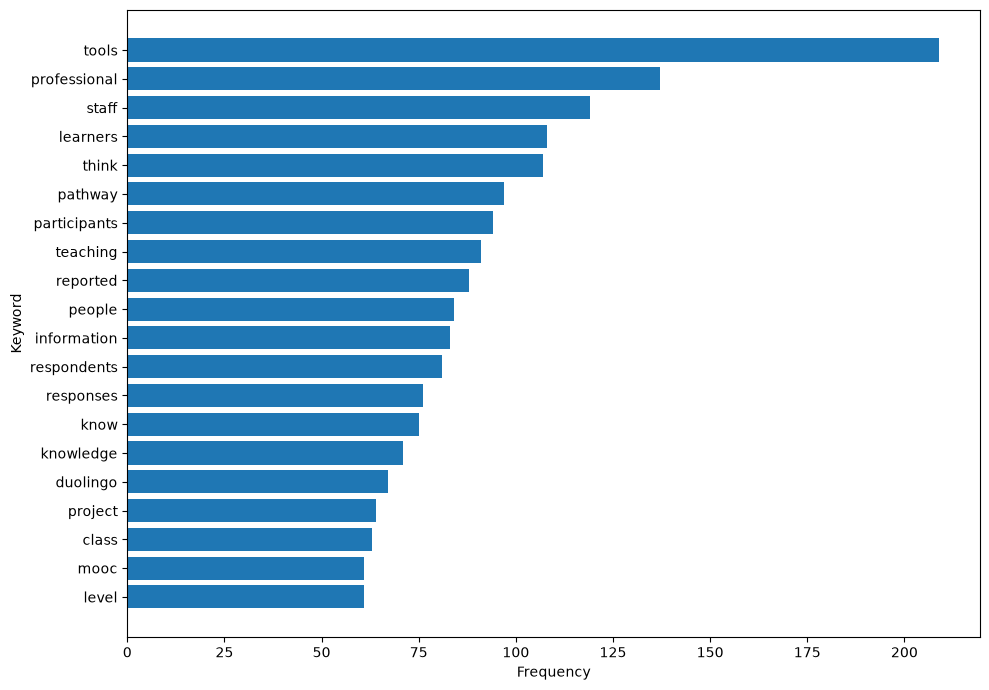


Ireland: 168 chunks, 4 documents, 14896 cleaned tokens.
Top 20 keywords for Ireland:


,keyword,frequency
0,tools,209
1,professional,137
2,staff,119
3,learners,108
4,think,107
5,pathway,97
6,participants,94
7,teaching,91
8,reported,88
9,people,84


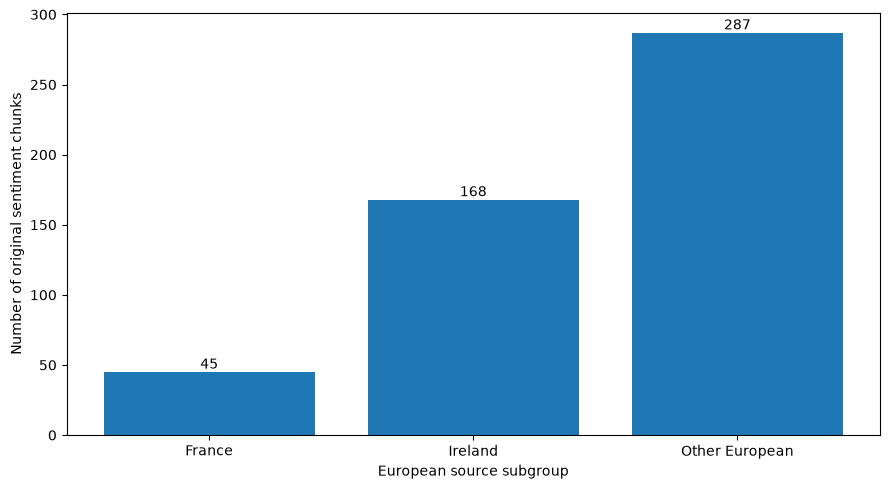


Generated PNG files:
 - progress/exploration/sentiment/img/chunk_count_by_scope_sentiment.png
 - progress/exploration/sentiment/img/top_20_keywords_europe_sentiment.png
 - progress/exploration/sentiment/img/top_20_keywords_france_sentiment.png
 - progress/exploration/sentiment/img/top_20_keywords_ireland_sentiment.png
 - progress/exploration/sentiment/img/wordcloud_europe_sentiment.png
 - progress/exploration/sentiment/img/wordcloud_france_sentiment.png
 - progress/exploration/sentiment/img/wordcloud_ireland_sentiment.png

Generated-output summary:


,scope,chunks,documents,cleaned_tokens,wordcloud_png,keywords_png
0,Europe,500,17,50373,wordcloud_europe_sentiment.png,top_20_keywords_europe_sentiment.png
1,France,45,4,3768,wordcloud_france_sentiment.png,top_20_keywords_france_sentiment.png
2,Ireland,168,4,14896,wordcloud_ireland_sentiment.png,top_20_keywords_ireland_sentiment.png


In [5]:
# Generate PNG outputs only.
#
# Every generated filename ends with `_sentiment.png`.
#
# Files created:
#   img/wordcloud_europe_sentiment.png
#   img/wordcloud_france_sentiment.png
#   img/wordcloud_ireland_sentiment.png
#   img/chunk_count_by_scope_sentiment.png
#   img/top_20_keywords_europe_sentiment.png
#   img/top_20_keywords_france_sentiment.png
#   img/top_20_keywords_ireland_sentiment.png
#
# Remove all earlier PNG outputs so stale names and stale clouds cannot remain.
for stale_png in IMG_DIR.glob("*.png"):
    stale_png.unlink()


SCOPE_CONFIG = {
    "Europe": {
        "mask": pd.Series(True, index=df.index),
        "wordcloud": "wordcloud_europe_sentiment.png",
        "keywords_plot": "top_20_keywords_europe_sentiment.png",
    },
    "France": {
        "mask": df["exploration_scope"].eq("France"),
        "wordcloud": "wordcloud_france_sentiment.png",
        "keywords_plot": "top_20_keywords_france_sentiment.png",
    },
    "Ireland": {
        "mask": df["exploration_scope"].eq("Ireland"),
        "wordcloud": "wordcloud_ireland_sentiment.png",
        "keywords_plot": "top_20_keywords_ireland_sentiment.png",
    },
}


def generate_scope_outputs(scope_name, scope_mask, config):
    scope_df = df.loc[scope_mask].copy()

    if scope_df.empty:
        print(f"\nSkipping {scope_name}: no eligible chunks.")
        return None

    tokens = [
        token
        for row_tokens in scope_df["clean_tokens"]
        for token in row_tokens
    ]

    if not tokens:
        print(f"\nSkipping {scope_name}: no cleaned tokens.")
        return None

    frequencies = Counter(tokens)
    keyword_df = pd.DataFrame(
        frequencies.most_common(100),
        columns=["keyword", "frequency"],
    )

    cloud = WordCloud(
        width=1600,
        height=900,
        background_color="white",
        max_words=120,
        collocations=False,
        random_state=42,
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(14, 8))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(
        IMG_DIR / config["wordcloud"],
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    top_20 = keyword_df.head(20).sort_values("frequency")

    plt.figure(figsize=(10, 7))
    plt.barh(top_20["keyword"], top_20["frequency"])
    plt.xlabel("Frequency")
    plt.ylabel("Keyword")
    plt.tight_layout()
    plt.savefig(
        IMG_DIR / config["keywords_plot"],
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    print(
        f"\n{scope_name}: {len(scope_df)} chunks, "
        f"{scope_df['doc_id'].nunique()} documents, "
        f"{len(tokens)} cleaned tokens."
    )
    print(f"Top 20 keywords for {scope_name}:")
    display(keyword_df.head(20))

    return {
        "scope": scope_name,
        "chunks": len(scope_df),
        "documents": scope_df["doc_id"].nunique(),
        "cleaned_tokens": len(tokens),
        "wordcloud_png": config["wordcloud"],
        "keywords_png": config["keywords_plot"],
    }


generated_outputs = []

for scope_name, config in SCOPE_CONFIG.items():
    result = generate_scope_outputs(
        scope_name,
        config["mask"],
        config,
    )
    if result is not None:
        generated_outputs.append(result)

# The source-count figure contains exactly three mutually exclusive bars.
plot_scope_order = [
    "France",
    "Ireland",
    "Other European",
]

plot_counts = (
    scope_summary.set_index("exploration_scope")
    .reindex(plot_scope_order)
    .fillna(0)
)

plt.figure(figsize=(9, 5))
bars = plt.bar(
    plot_counts.index,
    plot_counts["chunks"],
)
plt.xlabel("European source subgroup")
plt.ylabel("Number of original sentiment chunks")

# Print the exact count above each bar.
for bar, value in zip(
    bars,
    plot_counts["chunks"].astype(int),
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.savefig(
    IMG_DIR / "chunk_count_by_scope_sentiment.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()

print("\nGenerated PNG files:")
for png_path in sorted(IMG_DIR.glob("*.png")):
    print(" -", png_path.relative_to(PROJECT_ROOT))

print("\nGenerated-output summary:")
display(pd.DataFrame(generated_outputs))